In [1]:
%env OMP_NUM_THREADS=1

env: OMP_NUM_THREADS=1


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 72
import numpy as np
import random

In [4]:
import seaborn as sns
from scipy.stats import multivariate_normal
from matplotlib.patches import Ellipse
from sklearn.mixture import GaussianMixture

In [5]:
class BivariateMM:
    def __init__(self, initial_distribution, N, weights, para1, para2=None, max_iter=100, tolerance_level=0.01):
        self.initial_distribution = initial_distribution
        self.N = N  # number of samples
        self.weights = weights
        self.para1 = para1  # means
        self.para2 = para2  # covariances
        self.max_iter = max_iter
        self.tolerance_level = tolerance_level
        self.n_distributions = 2
        self.synthetic_data = None
        self.responsibility = None

    def generate_initial_data(self, weights, para1, para2=None):
        self.synthetic_data = np.vstack([np.random.multivariate_normal(m, c, int(w * self.N)) for w, m, c in zip(self.weights, self.para1, self.para2)])
        return self.synthetic_data

    def generate_initial_parameters(self):  
        self.para1 = self.synthetic_data[np.random.choice(self.N, self.n_distributions, replace=False)]
        self.para2 = np.array([np.eye(2) for _ in range(self.n_distributions)])
        self.weights = np.ones(self.n_distributions) / self.n_distributions

    def e_step(self):
        self.responsibilities = np.zeros((self.N, self.n_distributions))
        for k in range(self.n_distributions):
            pdf = multivariate_normal(mean=self.para1[k], cov=self.para2[k]).pdf(self.synthetic_data)
            self.responsibilities[:, k] = self.weights[k] * pdf
        self.responsibilities /= self.responsibilities.sum(axis=1, keepdims=True)

    def compute_cov(self, diff, responsibility_k):  # only for Gaussian distribution
        weighted_sum = np.dot((responsibility_k[:, np.newaxis] * diff).T, diff)
        return weighted_sum / responsibility_k.sum()

    def m_step(self):
        # update the parameters using the responsibilities
        for k in range(self.n_distributions):
            responsibility_k = self.responsibilities[:, k]
            total_responsibility_k = responsibility_k.sum()
            self.weights[k] = total_responsibility_k / self.N
            self.para1[k] = (self.synthetic_data * responsibility_k[:, np.newaxis]).sum(axis=0) / total_responsibility_k
            diff = self.synthetic_data - self.para1[k]
            self.para2[k] = self.compute_cov(diff, self.responsibilities[:, k])    

    def calculate_log_likelihood(self):
        log_likelihood = 0
        for k in range(self.n_distributions):
            pdf = multivariate_normal(mean=self.para1[k], cov=self.para2[k]).pdf(self.synthetic_data)
            pdf = np.maximum(pdf, 1e-10)  # avoid log(0)
            log_likelihood += np.sum(self.responsibilities[:, k] * (np.log(self.weights[k]) + np.log(pdf)))
        return log_likelihood

    def fit(self):
        self.generate_initial_parameters()
        log_likelihood = []
        for i in range(self.max_iter):
            # E-step: compute responsibilities
            self.e_step()
            # M-step: update parameters
            self.m_step()
            # Calculate and store log-likelihood
            log_likelihood.append(self.calculate_log_likelihood())
            # Check for convergence
            if i > 0 and np.abs(log_likelihood[-1] - log_likelihood[-2]) < self.tolerance_level:
                break
        return log_likelihood

    def generate_synthetic_data(self):
        n_samples_per_distribution = [round(n) for n in np.dot(self.N, self.weights)]
        synthetic_data = np.vstack([
            np.random.multivariate_normal(m, c, n)
            for m, c, n in zip(self.para1, self.para2, n_samples_per_distribution)
        ])
        np.random.shuffle(synthetic_data) 
        return synthetic_data

In [6]:
def plot_gmm_data(_ax, _data, _means, _covariances, _title):
    _ax.scatter(_data[:, 0], _data[:, 1], alpha=0.6)
    _ax.set(xlabel='x', ylabel='y', title=_title)

    for mean, cov in zip(_means, _covariances):
        _ax.scatter(mean[0], mean[1], marker='o', s=100, edgecolor='k', label='Mean')

        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        order = eigenvalues.argsort()[::-1]
        eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
        eigenvalues = np.sqrt(eigenvalues)
        angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))

        ell = Ellipse(mean, width=2*eigenvalues[0], height=2*eigenvalues[1], angle=angle, color='pink', alpha=0.5)
        _ax.add_patch(ell)

In [7]:
random_state = 0
np.random.seed(random_state)
random.seed(random_state)

N = 1000
true_weights=np.array([0.4, 0.6])
true_means=np.array([[0, 0], [3, 3]])
true_covariances=np.array([[[1, 0.5], [0.5, 1]], [[2, 0], [0, 2]]])

gmm = BivariateMM(initial_distribution='Gaussian', N=N, weights=true_weights, para1=true_means, para2=true_covariances)
original_d = gmm.generate_initial_data(true_weights, true_means, true_covariances)
log_likelihood = gmm.fit()

synthetic_d1 = gmm.generate_synthetic_data()

print(f"True means:\n{true_means}")
print(f"Learned means:\n{gmm.para1}")
print(f"True covariances:\n{true_covariances}")
print(f"Learned covariances:\n{gmm.para2}")

True means:
[[0 0]
 [3 3]]
Learned means:
[[3.15645897 3.1586856 ]
 [0.29344506 0.23646316]]
True covariances:
[[[1.  0.5]
  [0.5 1. ]]

 [[2.  0. ]
  [0.  2. ]]]
Learned covariances:
[[[ 1.76764016 -0.24244271]
  [-0.24244271  1.8067003 ]]

 [[ 1.24293684  0.70201921]
  [ 0.70201921  1.19641837]]]


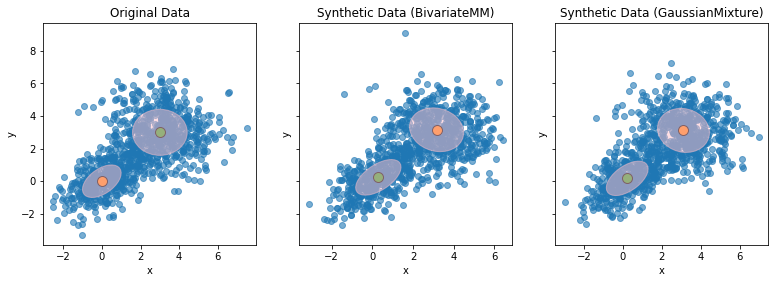

In [8]:
# Using built-in GaussianMixture to compare the results
built_in_gmm = GaussianMixture(n_components=len(true_means), random_state=random_state)
built_in_gmm.means_ = true_means
built_in_gmm.covariances_ = true_covariances
built_in_gmm.weights_ = true_weights
built_in_gmm.fit(original_d)

synthetic_d2, _ = built_in_gmm.sample(n_samples=1000)

learned_means = built_in_gmm.means_
learned_covariances = built_in_gmm.covariances_
learned_weights = built_in_gmm.weights_

fig, ax = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
plot_gmm_data(ax[0], original_d, true_means, true_covariances, 'Original Data')
plot_gmm_data(ax[1], synthetic_d1, gmm.para1, gmm.para2, 'Synthetic Data (BivariateMM)')
plot_gmm_data(ax[2], synthetic_d2, learned_means, learned_covariances, 'Synthetic Data (GaussianMixture)')
plt.show()

In [10]:
from distfit import distfit

dist1 = distfit(verbose='warning')
dist2 = distfit(verbose='warning')

d1 = dist1.fit_transform(original_d[:,0])
d2 = dist2.fit_transform(original_d[:,1])

syn1 = dist1.generate(N)
syn2 = dist2.generate(N)

[Text(0.5, 0, 'y'), Text(0.5, 1.0, 'y random variable')]

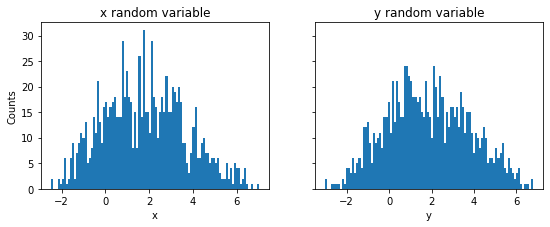

In [11]:
_, ax = plt.subplots(1 , 2, figsize=(9, 3), sharey=True)

ax[0].hist(syn1, bins=100)
ax[0].set(xlabel='x', ylabel='Counts', title='x random variable')
ax[1].hist(syn2, bins=100)
ax[1].set(xlabel='y', title='y random variable')